# Phase Retrieval via Dual Dispersion

This notebook presents a **normalized, educational validation study** for time-domain phase retrieval using two dispersive measurements. The workflow is intentionally compact and is meant for **algorithmic verification**, not full physical calibration.

## Connection to EC ENGR 279AS

EC ENGR 279AS spans wave-domain systems including photonics, electromagnetics, and microwave/RF topics. This notebook fits that scope by studying a **wave reconstruction inverse problem** in photonics: recovering phase from intensity-only measurements after propagation through different dispersive conditions.

## Theory bridge

The notebook combines two ideas:

1. **Gerchberg–Saxton (GS)** style iterative magnitude enforcement across related domains.
2. A **time-domain dispersive measurement model**, where two intensity measurements provide diversity for phase retrieval.

This is the conceptual bridge between the classical GS algorithm and the dispersive time-domain setting discussed in the course materials.

### References used for framing

- **[1]** R. W. Gerchberg and W. O. Saxton, *A practical algorithm for the determination of phase from image and diffraction plane pictures*, Optik, 1972.
- **[2]** D. R. Solli, S. Gupta, and B. Jalali, *Optical phase recovery in the dispersive Fourier transform*, Applied Physics Letters, 2009.


## Modeling note

All quantities below are represented in **normalized units**. The goal is to test whether the algorithm behaves sensibly under a simplified dual-dispersion model, not to reproduce a fully calibrated optical experiment.

In the language of [1], the core iteration is an alternating constraint-enforcement procedure. In the language of [2], the two dispersive measurements provide the diversity needed to make time-domain phase retrieval informative.


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, ifft, fftfreq

plt.rcParams.update({
    "font.size": 9,
    "axes.labelsize": 9,
    "axes.titlesize": 9,
    "legend.fontsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "figure.figsize": (4.4, 3.1),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "lines.linewidth": 1.6,
    "figure.dpi": 140,
    "savefig.dpi": 300,
})

## Signal model

A compact test signal is used as ground truth. To avoid an overly easy example, the phase includes both a quadratic chirp term and a small sinusoidal ripple.


In [12]:
def generate_signal(N=1024, ripple_scale=0.8):
    t = np.linspace(-1.0, 1.0, N, endpoint=False)
    amplitude = np.exp(-(t / 0.45) ** 2)
    true_phase = 5.0 * t**2 + ripple_scale * np.sin(6.0 * np.pi * t)
    field = amplitude * np.exp(1j * true_phase)
    return t, amplitude, true_phase, field

## Dispersive propagation model

Following the normalized frequency-domain viewpoint used in many instructional treatments, dispersion is represented here by a quadratic phase factor

$
H(\omega) = e^{-j\beta_2 \omega^2}.
$

This is the simplified operator that links the “object” field to each measurement condition. In the broader spirit of [2], changing the dispersion value changes the measurement diversity.


In [3]:
def apply_dispersion(field, beta2):
    w = fftfreq(len(field))
    transfer = np.exp(-1j * beta2 * w**2)
    return ifft(fft(field) * transfer)

def measure_intensity(field):
    return np.abs(field) ** 2

## Alignment and metrics

A recovered field is compared only after removing the **global phase ambiguity**, since phase retrieval generally does not determine absolute global phase.

The notebook uses:

- **aligned field error** for ground-truth validation
- **plane-1 and plane-2 intensity MSE** for measurement consistency


In [13]:
def align_global_phase(field_rec, field_true):
    phase_offset = np.angle(np.vdot(field_rec, field_true))
    return field_rec * np.exp(-1j * phase_offset)

def relative_field_error(field_rec, field_true):
    aligned = align_global_phase(field_rec, field_true)
    return np.linalg.norm(aligned - field_true) / (np.linalg.norm(field_true) + 1e-12)

def remove_linear_phase(t, phase):
    coeff = np.polyfit(t, phase, 1)
    trend = np.polyval(coeff, t)
    return phase - trend, coeff

## Gerchberg–Saxton-style retrieval

The iteration below is written as a compact educational variant of a dual-constraint retrieval loop:

1. propagate to dispersion setting 1 and enforce measured magnitude,
2. propagate to dispersion setting 2 and enforce measured magnitude,
3. track mismatch at **both** measurement planes.

This is not presented as a full laboratory-grade solver; it is a clean notebook implementation meant to illustrate the alternating-constraint logic discussed in [1] and the dual-dispersion motivation described in [2].


In [14]:
def gs_dual_dispersion(intensity_1, intensity_2, beta2_1, beta2_2, iterations=80, seed=0):
    rng = np.random.default_rng(seed)
    phase_guess = rng.uniform(0.0, 2.0 * np.pi, size=len(intensity_1))
    field = np.sqrt(intensity_1) * np.exp(1j * phase_guess)

    error_plane_1 = []
    error_plane_2 = []

    for _ in range(iterations):
        field_1 = apply_dispersion(field, beta2_1)
        field_1 = np.sqrt(intensity_1) * np.exp(1j * np.angle(field_1))

        field_2 = apply_dispersion(field_1, beta2_2 - beta2_1)
        field_2 = np.sqrt(intensity_2) * np.exp(1j * np.angle(field_2))

        field = apply_dispersion(field_2, -beta2_2)

        pred_1 = measure_intensity(apply_dispersion(field, beta2_1))
        pred_2 = measure_intensity(apply_dispersion(field, beta2_2))

        error_plane_1.append(np.mean((pred_1 - intensity_1) ** 2))
        error_plane_2.append(np.mean((pred_2 - intensity_2) ** 2))

    return field, np.asarray(error_plane_1), np.asarray(error_plane_2)

## Phase sanity check

Before interpreting retrieval results, the notebook explicitly plots the **intended true phase** used to generate the synthetic field. This avoids confusing a flat or trivial source phase with a failed recovery.

In the spirit of Gerchberg–Saxton [1], the algorithm enforces magnitude constraints iteratively. In the dual-dispersion setting motivated by Solli, Gupta, and Jalali [2], the two measurements should provide diversity that helps constrain the phase.

## Single-run qualitative comparison

This first experiment checks whether amplitude and unwrapped phase behave plausibly for one reconstruction.


In [15]:
t, amplitude_true, phase_true, field_true = generate_signal()

beta2_1 = 25.0
beta2_2 = 60.0

intensity_1 = measure_intensity(apply_dispersion(field_true, beta2_1))
intensity_2 = measure_intensity(apply_dispersion(field_true, beta2_2))

field_rec, mse_1, mse_2 = gs_dual_dispersion(
    intensity_1, intensity_2, beta2_1, beta2_2, iterations=100, seed=7
)
field_rec = align_global_phase(field_rec, field_true)

phase_rec_wrapped = np.angle(field_rec)
phase_true_wrapped = np.angle(field_true)

phase_true_unwrapped = np.unwrap(phase_true_wrapped)
phase_rec_unwrapped = np.unwrap(phase_rec_wrapped)

phase_true_detrended, coeff_true = remove_linear_phase(t, phase_true_unwrapped)
phase_rec_detrended, coeff_rec = remove_linear_phase(t, phase_rec_unwrapped)

print("True phase polynomial slope/intercept:", coeff_true)
print("Recovered phase polynomial slope/intercept:", coeff_rec)
print("Aligned relative field error:", float(relative_field_error(field_rec, field_true)))

True phase polynomial slope/intercept: [-0.13707532 -4.61664932]
Recovered phase polynomial slope/intercept: [-17.40898555 -36.47214309]
Aligned relative field error: 1.3863554558708608


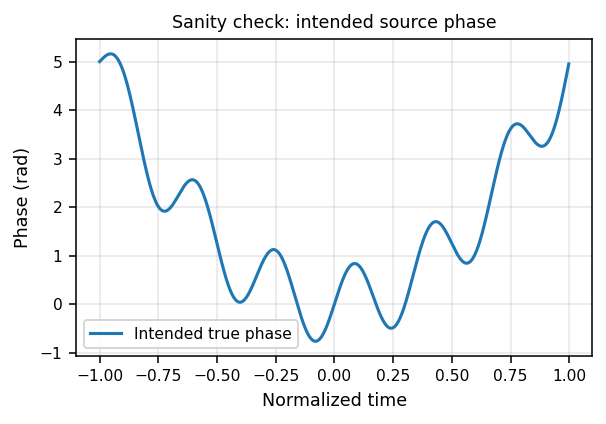

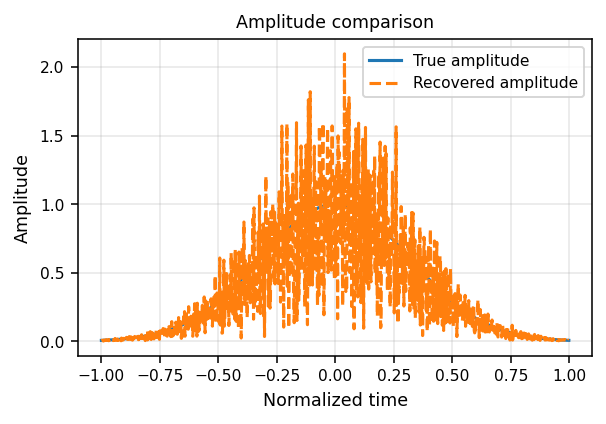

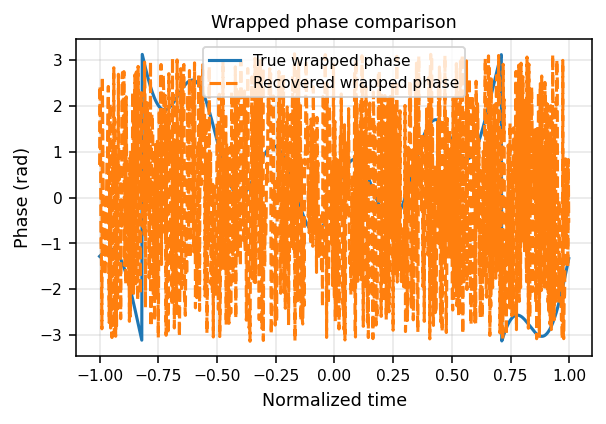

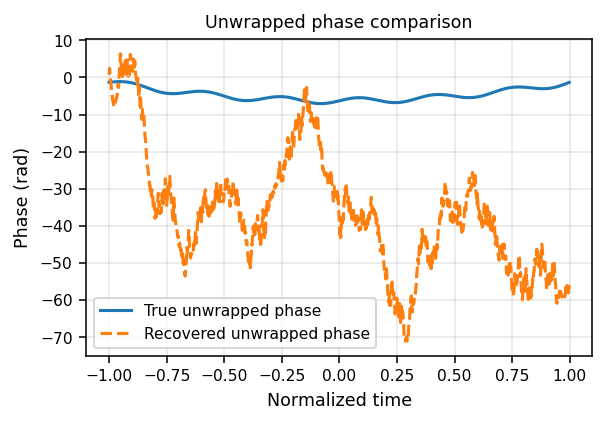

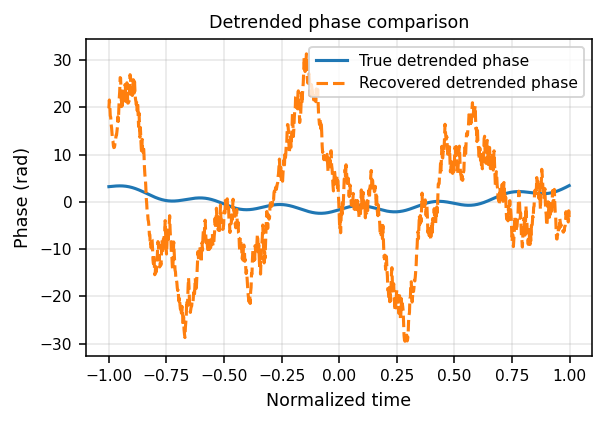

In [16]:
fig, ax = plt.subplots()
ax.plot(t, phase_true, label="Intended true phase")
ax.set_xlabel("Normalized time")
ax.set_ylabel("Phase (rad)")
ax.set_title("Sanity check: intended source phase")
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots()
ax.plot(t, np.abs(field_true), label="True amplitude")
ax.plot(t, np.abs(field_rec), "--", label="Recovered amplitude")
ax.set_xlabel("Normalized time")
ax.set_ylabel("Amplitude")
ax.set_title("Amplitude comparison")
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots()
ax.plot(t, phase_true_wrapped, label="True wrapped phase")
ax.plot(t, phase_rec_wrapped, "--", label="Recovered wrapped phase")
ax.set_xlabel("Normalized time")
ax.set_ylabel("Phase (rad)")
ax.set_title("Wrapped phase comparison")
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots()
ax.plot(t, phase_true_unwrapped, label="True unwrapped phase")
ax.plot(t, phase_rec_unwrapped, "--", label="Recovered unwrapped phase")
ax.set_xlabel("Normalized time")
ax.set_ylabel("Phase (rad)")
ax.set_title("Unwrapped phase comparison")
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots()
ax.plot(t, phase_true_detrended, label="True detrended phase")
ax.plot(t, phase_rec_detrended, "--", label="Recovered detrended phase")
ax.set_xlabel("Normalized time")
ax.set_ylabel("Phase (rad)")
ax.set_title("Detrended phase comparison")
ax.legend()
plt.tight_layout()
plt.show()

## Convergence diagnostics

A stronger notebook should track both measurement-plane errors, not just one. That is done here.


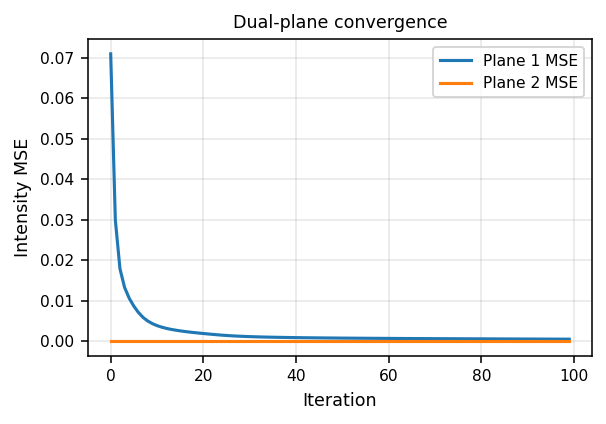

In [17]:
fig, ax = plt.subplots()
ax.plot(mse_1, label="Plane 1 MSE")
ax.plot(mse_2, label="Plane 2 MSE")
ax.set_xlabel("Iteration")
ax.set_ylabel("Intensity MSE")
ax.set_title("Dual-plane convergence")
ax.legend()
plt.tight_layout()
plt.show()

## Statistical validation: repeated trials

A single plot is not enough to justify interpretation. This section repeats the reconstruction with different random initializations and records the aligned field error. That makes the notebook more like a **small Monte Carlo validation** than a single example.


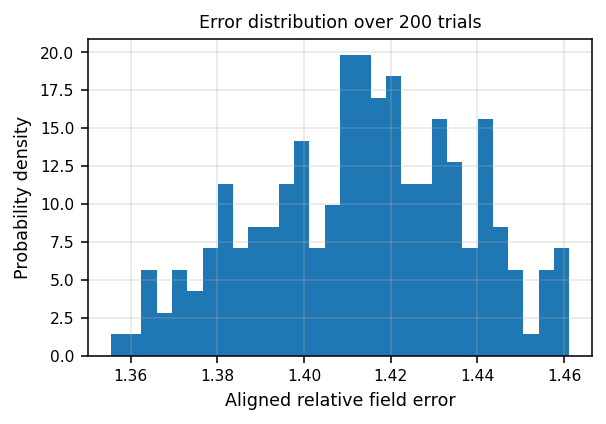

Mean error: 1.4133205775395503
Std error: 0.02394605932146557


In [18]:
trial_errors = []

for trial in range(200):
    _, _, _, field_true_trial = generate_signal()
    intensity_1 = measure_intensity(apply_dispersion(field_true_trial, beta2_1))
    intensity_2 = measure_intensity(apply_dispersion(field_true_trial, beta2_2))

    field_rec_trial, _, _ = gs_dual_dispersion(
        intensity_1, intensity_2, beta2_1, beta2_2, iterations=100, seed=trial
    )
    trial_errors.append(relative_field_error(field_rec_trial, field_true_trial))

trial_errors = np.asarray(trial_errors)

fig, ax = plt.subplots()
ax.hist(trial_errors, bins=30, density=True)
ax.set_xlabel("Aligned relative field error")
ax.set_ylabel("Probability density")
ax.set_title("Error distribution over 200 trials")
plt.tight_layout()
plt.show()

print("Mean error:", float(np.mean(trial_errors)))
print("Std error:", float(np.std(trial_errors)))

## Parameter study: dispersion diversity

This section tests the qualitative claim that **more distinct measurement conditions** tend to help retrieval. In the normalized model below, the second dispersion setting is swept while the first is fixed.

This is the key place where the notebook connects its experimental trend to the diversity idea emphasized in [2].


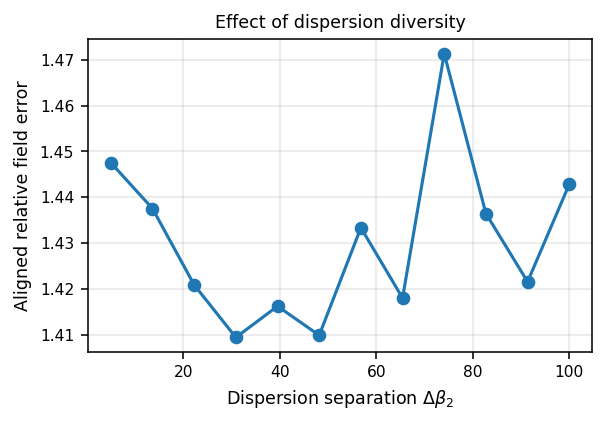

In [19]:
dispersion_deltas = np.linspace(5.0, 100.0, 12)
dispersion_errors = []

for delta in dispersion_deltas:
    _, _, _, field_true_delta = generate_signal()
    intensity_1 = measure_intensity(apply_dispersion(field_true_delta, beta2_1))
    intensity_2 = measure_intensity(apply_dispersion(field_true_delta, beta2_1 + delta))

    field_rec_delta, _, _ = gs_dual_dispersion(
        intensity_1, intensity_2, beta2_1, beta2_1 + delta, iterations=100, seed=3
    )
    dispersion_errors.append(relative_field_error(field_rec_delta, field_true_delta))

dispersion_errors = np.asarray(dispersion_errors)

fig, ax = plt.subplots()
ax.plot(dispersion_deltas, dispersion_errors, marker="o")
ax.set_xlabel(r"Dispersion separation $\Delta \beta_2$")
ax.set_ylabel("Aligned relative field error")
ax.set_title("Effect of dispersion diversity")
plt.tight_layout()
plt.show()

## Noise stress test

To avoid an overly optimistic interpretation, the same retrieval is tested under additive intensity noise. This is still a simplified noise model, but it helps distinguish between “works in one clean case” and “shows some robustness.”


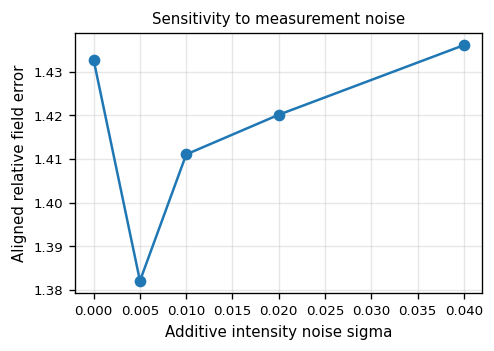

In [10]:
def add_intensity_noise(intensity, sigma=0.01, seed=0):
    rng = np.random.default_rng(seed)
    noisy = intensity + sigma * rng.standard_normal(size=intensity.shape)
    return np.clip(noisy, 0.0, None)

noise_levels = [0.0, 0.005, 0.01, 0.02, 0.04]
noise_errors = []

_, field_true_noise = generate_signal()
clean_1 = measure_intensity(apply_dispersion(field_true_noise, beta2_1))
clean_2 = measure_intensity(apply_dispersion(field_true_noise, beta2_2))

for i, sigma in enumerate(noise_levels):
    noisy_1 = add_intensity_noise(clean_1, sigma=sigma, seed=100 + i)
    noisy_2 = add_intensity_noise(clean_2, sigma=sigma, seed=200 + i)

    field_rec_noise, _, _ = gs_dual_dispersion(
        noisy_1, noisy_2, beta2_1, beta2_2, iterations=80, seed=1
    )
    noise_errors.append(relative_field_error(field_rec_noise, field_true_noise))

fig, ax = plt.subplots()
ax.plot(noise_levels, noise_errors, marker="o")
ax.set_xlabel("Additive intensity noise sigma")
ax.set_ylabel("Aligned relative field error")
ax.set_title("Sensitivity to measurement noise")
plt.tight_layout()
plt.show()


## Interpretation update

If the recovered phase still differs strongly from the true phase after:
- global phase alignment,
- explicit wrapped/unwrapped comparison,
- and linear-trend removal,

then the remaining mismatch should be interpreted as a **real reconstruction limitation** of the simplified solver/model, not as a harmless plotting artifact.

That makes the notebook stronger academically, because it distinguishes:
- benign ambiguity,
- unwrap artifacts,
- and actual failure to recover phase.

## References

[1] R. W. Gerchberg and W. O. Saxton, “A practical algorithm for the determination of phase from image and diffraction plane pictures,” *Optik*, 35, 237–246, 1972.

[2] D. R. Solli, S. Gupta, and B. Jalali, “Optical phase recovery in the dispersive Fourier transform,” *Applied Physics Letters*, 95, 231108, 2009.
